In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import mediapipe as mp
from skimage.feature import hog

from sklearn.model_selection import train_test_split

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("MediaPipe:", mp.__version__)
print("Preprocessing environment ready ✅")

NumPy: 2.5.2
OpenCV: 5.0.0
MediaPipe: 1.0.1
Preprocessing environment ready ✅


In [2]:
# Define training dataset path

TRAIN_DIR = Path(
    "../data/raw/asl_alphabet/"
    "asl_alphabet_train/asl_alphabet_train"
)

# Collect image paths and labels

dataset = []

for class_folder in sorted(TRAIN_DIR.iterdir()):
    if not class_folder.is_dir():
        continue

    label = class_folder.name

    for image_path in class_folder.iterdir():
        if image_path.is_file():
            dataset.append({
                "image_path": str(image_path),
                "label": label
            })

# Create DataFrame

df = pd.DataFrame(dataset)

print("Dataset shape:", df.shape)
print("Total images:", len(df))
print("Total classes:", df["label"].nunique())

df.head()

Dataset shape: (87000, 2)
Total images: 87000
Total classes: 29


,image_path,label
0,../data/raw/asl_alphabet/asl_alphabet_train/as...,A
1,../data/raw/asl_alphabet/asl_alphabet_train/as...,A
2,../data/raw/asl_alphabet/asl_alphabet_train/as...,A
3,../data/raw/asl_alphabet/asl_alphabet_train/as...,A
4,../data/raw/asl_alphabet/asl_alphabet_train/as...,A


In [3]:
# Create reproducible Train / Validation / Test splits

RANDOM_STATE = 42

# Step 1: 80% training, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

# Step 2: Split remaining 20% equally
# 10% validation + 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Training images: 69600
Validation images: 8700
Test images: 8700

Total: 87000


In [4]:
# Verify class distribution in each split

print("TRAIN CLASS COUNTS")
print(train_df["label"].value_counts().sort_index())

print("\nVALIDATION CLASS COUNTS")
print(val_df["label"].value_counts().sort_index())

print("\nTEST CLASS COUNTS")
print(test_df["label"].value_counts().sort_index())

TRAIN CLASS COUNTS
label
A          2400
B          2400
C          2400
D          2400
E          2400
F          2400
G          2400
H          2400
I          2400
J          2400
K          2400
L          2400
M          2400
N          2400
O          2400
P          2400
Q          2400
R          2400
S          2400
T          2400
U          2400
V          2400
W          2400
X          2400
Y          2400
Z          2400
del        2400
nothing    2400
space      2400
Name: count, dtype: int64

VALIDATION CLASS COUNTS
label
A          300
B          300
C          300
D          300
E          300
F          300
G          300
H          300
I          300
J          300
K          300
L          300
M          300
N          300
O          300
P          300
Q          300
R          300
S          300
T          300
U          300
V          300
W          300
X          300
Y          300
Z          300
del        300
nothing    300
space      300
Name: count, dtype:

In [23]:
# Save reproducible dataset splits

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "validation.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)

print("Dataset splits saved successfully ✅")
print()
print("Train CSV:", PROCESSED_DIR / "train.csv")
print("Validation CSV:", PROCESSED_DIR / "validation.csv")
print("Test CSV:", PROCESSED_DIR / "test.csv")

Dataset splits saved successfully ✅

Train CSV: ../data/processed/train.csv
Validation CSV: ../data/processed/validation.csv
Test CSV: ../data/processed/test.csv


In [6]:
# Test image preprocessing pipeline

IMG_SIZE = 128

sample_path = train_df.iloc[0]["image_path"]
sample_label = train_df.iloc[0]["label"]

# Load image
image = cv2.imread(sample_path)

# OpenCV loads images as BGR
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize from 200x200 to 128x128
image_resized = cv2.resize(
    image_rgb,
    (IMG_SIZE, IMG_SIZE)
)

# Normalize pixel values from 0-255 to 0-1
image_normalized = image_resized.astype(np.float32) / 255.0

print("Label:", sample_label)

print("\nOriginal shape:")
print(image.shape)

print("\nResized shape:")
print(image_resized.shape)

print("\nNormalized dtype:")
print(image_normalized.dtype)

print("\nNormalized pixel range:")
print(
    image_normalized.min(),
    "to",
    image_normalized.max()
)

Label: A

Original shape:
(200, 200, 3)

Resized shape:
(128, 128, 3)

Normalized dtype:
float32

Normalized pixel range:
0.0 to 1.0


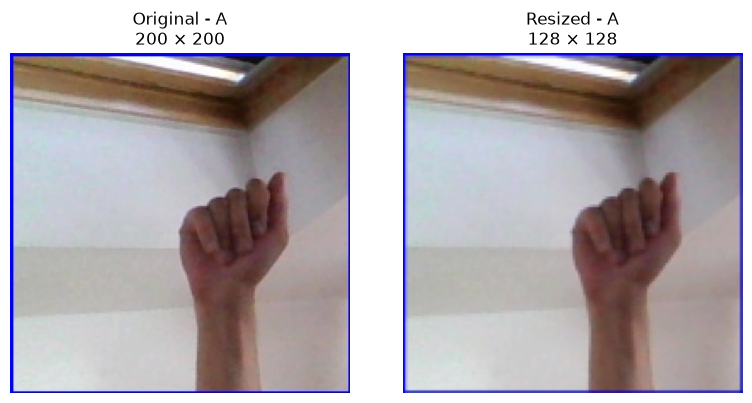

In [9]:
# Compare original and resized image

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title(f"Original - {sample_label}\n200 × 200")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_resized)
plt.title(f"Resized - {sample_label}\n128 × 128")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
def preprocess_image(image_path, img_size=128):
    """
    Load, resize, convert color, and normalize an image.
    """

    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(
        image,
        (img_size, img_size)
    )

    image = image.astype(np.float32) / 255.0

    return image

In [11]:
test_image = preprocess_image(train_df.iloc[0]["image_path"])

print("Processed shape:", test_image.shape)
print("Data type:", test_image.dtype)
print("Pixel range:", test_image.min(), "to", test_image.max())

Processed shape: (128, 128, 3)
Data type: float32
Pixel range: 0.0 to 1.0


In [ ]:
# Initialize MediaPipe Hand Landmarker

MODEL_PATH = "../models/mediapipe/hand_landmarker.task"

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=MODEL_PATH
    ),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1
)

landmarker = HandLandmarker.create_from_options(options)

print("MediaPipe Hand Landmarker loaded ✅")

In [1]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("Has tasks:", hasattr(mp, "tasks"))

if hasattr(mp, "tasks"):
    print("Tasks module available ✅")

MediaPipe version: 1.0.1
Has tasks: True
Tasks module available ✅


In [2]:
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

print("BaseOptions loaded ✅")
print("HandLandmarker loaded ✅")
print("HandLandmarkerOptions loaded ✅")
print("RunningMode loaded ✅")

BaseOptions loaded ✅
HandLandmarker loaded ✅
HandLandmarkerOptions loaded ✅
RunningMode loaded ✅


In [3]:
from pathlib import Path

MODEL_PATH = Path("../models/mediapipe/hand_landmarker.task")

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

if MODEL_PATH.exists():
    print("Model size:", round(MODEL_PATH.stat().st_size / (1024 * 1024), 2), "MB")

Model path: ../models/mediapipe/hand_landmarker.task
Model exists: True
Model size: 7.46 MB


In [22]:
# Extract HOG features from one ASL image

sample_path = train_df.iloc[0]["image_path"]
sample_label = train_df.iloc[0]["label"]

# Load image
image = cv2.imread(sample_path)

# Convert BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize
image_resized = cv2.resize(image_rgb, (128, 128))

# Convert to grayscale for HOG
image_gray = cv2.cvtColor(image_resized, cv2.COLOR_RGB2GRAY)

# Extract HOG features
hog_features, hog_image = hog(
    image_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True
)

print("Label:", sample_label)
print("Input image shape:", image_resized.shape)
print("Grayscale shape:", image_gray.shape)
print("Number of HOG features:", len(hog_features))
print("HOG feature shape:", hog_features.shape)

Label: A
Input image shape: (128, 128, 3)
Grayscale shape: (128, 128)
Number of HOG features: 8100
HOG feature shape: (8100,)


In [9]:
# Reload the already-saved dataset splits

from pathlib import Path
import pandas as pd

PROCESSED_DIR = Path("../data/processed")

train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "validation.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nDataset splits loaded successfully ✅")

Training images: 69600
Validation images: 8700
Test images: 8700

Dataset splits loaded successfully ✅


In [11]:
# Test HOG feature extraction on one image

sample_path = train_df.iloc[0]["image_path"]
sample_label = train_df.iloc[0]["label"]

# Read image
image = cv2.imread(sample_path)

# Convert BGR -> RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize
image_resized = cv2.resize(image_rgb, (128, 128))

# Convert to grayscale
image_gray = cv2.cvtColor(
    image_resized,
    cv2.COLOR_RGB2GRAY
)

# Extract HOG features
hog_features, hog_image = hog(
    image_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True
)

print("Label:", sample_label)
print("Input image shape:", image_resized.shape)
print("Grayscale shape:", image_gray.shape)
print("Number of HOG features:", len(hog_features))
print("HOG feature shape:", hog_features.shape)

Label: A
Input image shape: (128, 128, 3)
Grayscale shape: (128, 128)
Number of HOG features: 8100
HOG feature shape: (8100,)


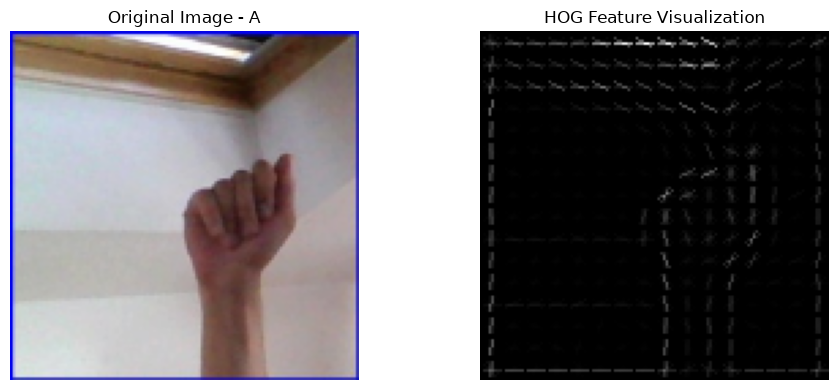

In [12]:
# Visualize original image and HOG representation

plt.figure(figsize=(10, 4))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image_resized)
plt.title(f"Original Image - {sample_label}")
plt.axis("off")

# HOG visualization
plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Feature Visualization")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
def extract_hog_features(image_path, img_size=128):
    """
    Load an ASL image and extract HOG features.
    
    Returns:
        numpy.ndarray: HOG feature vector
    """

    # Load image
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Convert BGR -> RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    image = cv2.resize(
        image,
        (img_size, img_size)
    )

    # Convert to grayscale
    image_gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    # Extract HOG features
    features = hog(
        image_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )

    return features

In [14]:
test_path = train_df.iloc[0]["image_path"]
test_label = train_df.iloc[0]["label"]

test_features = extract_hog_features(test_path)

print("Label:", test_label)
print("Feature type:", type(test_features))
print("Feature shape:", test_features.shape)
print("Number of features:", len(test_features))

print("\nHOG feature extractor working ✅")

Label: A
Feature type: <class 'numpy.ndarray'>
Feature shape: (8100,)
Number of features: 8100

HOG feature extractor working ✅


In [15]:
import time

# Benchmark HOG extraction on 100 images

sample_df = train_df.sample(
    n=100,
    random_state=42
)

start_time = time.time()

sample_features = []

for image_path in sample_df["image_path"]:
    features = extract_hog_features(image_path)
    sample_features.append(features)

sample_features = np.array(sample_features)

elapsed_time = time.time() - start_time

print("Images processed:", len(sample_features))
print("Feature matrix shape:", sample_features.shape)
print("Time taken:", round(elapsed_time, 2), "seconds")
print(
    "Average time per image:",
    round(elapsed_time / len(sample_features), 4),
    "seconds"
)

print("\n100-image HOG benchmark completed ✅")

Images processed: 100
Feature matrix shape: (100, 8100)
Time taken: 0.21 seconds
Average time per image: 0.0021 seconds

100-image HOG benchmark completed ✅


In [16]:
# Test HOG extraction on 1000 training images

hog_test_df = train_df.sample(
    n=1000,
    random_state=42
)

start_time = time.time()

X_hog_test = np.empty(
    (len(hog_test_df), 8100),
    dtype=np.float32
)

y_hog_test = hog_test_df["label"].to_numpy()

for i, image_path in enumerate(hog_test_df["image_path"]):
    X_hog_test[i] = extract_hog_features(image_path).astype(np.float32)

elapsed_time = time.time() - start_time

print("X shape:", X_hog_test.shape)
print("y shape:", y_hog_test.shape)
print("Data type:", X_hog_test.dtype)

print(
    "Memory used:",
    round(X_hog_test.nbytes / (1024 ** 2), 2),
    "MB"
)

print("Time taken:", round(elapsed_time, 2), "seconds")

print("\n1000-image extraction successful ✅")

X shape: (1000, 8100)
y shape: (1000,)
Data type: float32
Memory used: 30.9 MB
Time taken: 1.93 seconds

1000-image extraction successful ✅


In [17]:
# Create balanced baseline training subset

SAMPLES_PER_CLASS = 500

baseline_train_df = (
    train_df
    .groupby("label", group_keys=False)
    .sample(
        n=SAMPLES_PER_CLASS,
        random_state=42
    )
    .reset_index(drop=True)
)

print("Baseline training images:", len(baseline_train_df))
print("Number of classes:", baseline_train_df["label"].nunique())

print("\nImages per class:")
print(baseline_train_df["label"].value_counts().sort_index())

Baseline training images: 14500
Number of classes: 29

Images per class:
label
A          500
B          500
C          500
D          500
E          500
F          500
G          500
H          500
I          500
J          500
K          500
L          500
M          500
N          500
O          500
P          500
Q          500
R          500
S          500
T          500
U          500
V          500
W          500
X          500
Y          500
Z          500
del        500
nothing    500
space      500
Name: count, dtype: int64


In [18]:
# Save baseline training subset

BASELINE_CSV = PROCESSED_DIR / "baseline_train.csv"

baseline_train_df.to_csv(
    BASELINE_CSV,
    index=False
)

print("Baseline dataset saved ✅")
print("Path:", BASELINE_CSV)
print("Images:", len(baseline_train_df))

Baseline dataset saved ✅
Path: ../data/processed/baseline_train.csv
Images: 14500


In [19]:
# Extract HOG features for baseline training dataset

import time

num_images = len(baseline_train_df)
num_features = 8100

X_train_hog = np.empty(
    (num_images, num_features),
    dtype=np.float32
)

y_train_hog = baseline_train_df["label"].to_numpy()

start_time = time.time()

for i, image_path in enumerate(baseline_train_df["image_path"]):
    X_train_hog[i] = extract_hog_features(image_path).astype(np.float32)

    if (i + 1) % 1000 == 0:
        print(f"Processed {i + 1}/{num_images}")

elapsed_time = time.time() - start_time

print("\nHOG extraction completed ✅")
print("X_train_hog shape:", X_train_hog.shape)
print("y_train_hog shape:", y_train_hog.shape)
print("Data type:", X_train_hog.dtype)

print(
    "Memory:",
    round(X_train_hog.nbytes / (1024 ** 2), 2),
    "MB"
)

print("Time:", round(elapsed_time, 2), "seconds")

Processed 1000/14500
Processed 2000/14500
Processed 3000/14500
Processed 4000/14500
Processed 5000/14500
Processed 6000/14500
Processed 7000/14500
Processed 8000/14500
Processed 9000/14500
Processed 10000/14500
Processed 11000/14500
Processed 12000/14500
Processed 13000/14500
Processed 14000/14500

HOG extraction completed ✅
X_train_hog shape: (14500, 8100)
y_train_hog shape: (14500,)
Data type: float32
Memory: 448.04 MB
Time: 27.13 seconds


In [20]:
# Create feature directory

FEATURES_DIR = Path("../data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print("Features directory:", FEATURES_DIR)

Features directory: ../data/features


In [21]:
# Save HOG features and labels

np.save(
    FEATURES_DIR / "X_train_hog.npy",
    X_train_hog
)

np.save(
    FEATURES_DIR / "y_train_hog.npy",
    y_train_hog
)

print("HOG features saved successfully ✅")
print("X:", FEATURES_DIR / "X_train_hog.npy")
print("y:", FEATURES_DIR / "y_train_hog.npy")

HOG features saved successfully ✅
X: ../data/features/X_train_hog.npy
y: ../data/features/y_train_hog.npy


In [24]:
# Extract HOG features for validation dataset

num_val_images = len(val_df)
num_features = 8100

X_val_hog = np.empty(
    (num_val_images, num_features),
    dtype=np.float32
)

y_val_hog = val_df["label"].to_numpy()

start_time = time.time()

for i, image_path in enumerate(val_df["image_path"]):
    X_val_hog[i] = extract_hog_features(image_path).astype(np.float32)

    if (i + 1) % 1000 == 0:
        print(f"Processed {i + 1}/{num_val_images}")

elapsed_time = time.time() - start_time

print("\nValidation HOG extraction completed ✅")
print("X_val_hog shape:", X_val_hog.shape)
print("y_val_hog shape:", y_val_hog.shape)
print("Data type:", X_val_hog.dtype)

print(
    "Memory:",
    round(X_val_hog.nbytes / (1024 ** 2), 2),
    "MB"
)

print("Time:", round(elapsed_time, 2), "seconds")

Processed 1000/8700
Processed 2000/8700
Processed 3000/8700
Processed 4000/8700
Processed 5000/8700
Processed 6000/8700
Processed 7000/8700
Processed 8000/8700

Validation HOG extraction completed ✅
X_val_hog shape: (8700, 8100)
y_val_hog shape: (8700,)
Data type: float32
Memory: 268.82 MB
Time: 16.74 seconds


In [25]:
# Save validation HOG features

np.save(
    FEATURES_DIR / "X_val_hog.npy",
    X_val_hog
)

np.save(
    FEATURES_DIR / "y_val_hog.npy",
    y_val_hog
)

print("Validation HOG features saved successfully ✅")
print("X:", FEATURES_DIR / "X_val_hog.npy")
print("y:", FEATURES_DIR / "y_val_hog.npy")

Validation HOG features saved successfully ✅
X: ../data/features/X_val_hog.npy
y: ../data/features/y_val_hog.npy


In [26]:
# Extract HOG features for test dataset

num_test_images = len(test_df)
num_features = 8100

X_test_hog = np.empty(
    (num_test_images, num_features),
    dtype=np.float32
)

y_test_hog = test_df["label"].to_numpy()

start_time = time.time()

for i, image_path in enumerate(test_df["image_path"]):

    X_test_hog[i] = extract_hog_features(
        image_path
    ).astype(np.float32)

    if (i + 1) % 1000 == 0:
        print(
            f"Processed {i + 1}/{num_test_images}"
        )

elapsed_time = time.time() - start_time

print("\nTest HOG extraction completed ✅")

print(
    "X_test_hog shape:",
    X_test_hog.shape
)

print(
    "y_test_hog shape:",
    y_test_hog.shape
)

print(
    "Data type:",
    X_test_hog.dtype
)

print(
    "Memory:",
    round(
        X_test_hog.nbytes / (1024 ** 2),
        2
    ),
    "MB"
)

print(
    "Time:",
    round(elapsed_time, 2),
    "seconds"
)

Processed 1000/8700
Processed 2000/8700
Processed 3000/8700
Processed 4000/8700
Processed 5000/8700
Processed 6000/8700
Processed 7000/8700
Processed 8000/8700

Test HOG extraction completed ✅
X_test_hog shape: (8700, 8100)
y_test_hog shape: (8700,)
Data type: float32
Memory: 268.82 MB
Time: 16.7 seconds


In [27]:
# Save test HOG features

np.save(
    FEATURES_DIR / "X_test_hog.npy",
    X_test_hog
)

np.save(
    FEATURES_DIR / "y_test_hog.npy",
    y_test_hog
)

print("Test HOG features saved successfully ✅")

print(
    "X:",
    FEATURES_DIR / "X_test_hog.npy"
)

print(
    "y:",
    FEATURES_DIR / "y_test_hog.npy"
)

Test HOG features saved successfully ✅
X: ../data/features/X_test_hog.npy
y: ../data/features/y_test_hog.npy
